# Hafta 4 · Ders 8 — QR Ayrışımı

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Gram–Schmidt geçen derste gizlice bir çarpanlama üretti: $A = QR$; $Q$ ortonormal ve $R$
üst-üçgensel. Bu defter bunu açık hâle getirir ve işe koşar.

QR, en küçük kareleri çözmenin *doğru* yoludur. $X^\top X$'i oluşturup koşul sayısının karesini almak
yerine, QR doğrudan $Q$ ve $R$ ile çalışır ve problemi verinin izin verdiği kadar iyi koşullanmış tutar.
QR'yi iki yolla inşa edeceğiz — Gram–Schmidt'ten ve (ön gösterim) Householder yansımalarından — ve
onun, Hafta 3'te normal denklemlerin tam olarak başarısız olduğu yerde başarılı olmasını izleyeceğiz.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Gram–Schmidt'ten QR

Çarpanlama doğrudan Gram–Schmidt'ten çıkar: ortonormalleştirilmiş vektörler $Q$'yu oluşturur ve yol
boyunca hesapladığımız izdüşüm katsayıları üst-üçgensel $R$'yi oluşturur. Somut olarak $R = Q^\top A$
ve her $\mathbf{a}_k$ yalnızca $\mathbf{q}_1,\dots,\mathbf{q}_k$'yi kullandığı için, $R$ üst-üçgenseldir.

$$ A = QR, \qquad Q^\top Q = I, \qquad R \text{ üst-üçgensel} $$

In [2]:
def qr_gram_schmidt(A):
    A = np.asarray(A, float)
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for k in range(n):
        v = A[:, k].copy()
        for j in range(k):
            R[j, k] = Q[:, j] @ A[:, k]          # izdüşüm katsayısı
            v -= R[j, k] * Q[:, j]
        R[k, k] = np.linalg.norm(v)
        Q[:, k] = v / R[k, k]
    return Q, R

A = np.array([[1.0, 1.0, 0.0],
              [1.0, 0.0, 1.0],
              [0.0, 1.0, 1.0],
              [1.0, 1.0, 1.0]])
Q, R = qr_gram_schmidt(A)
print("Q (4×3, ortonormal sütunlar):\n", Q)
print("\nR (3×3, üst-üçgensel):\n", R)
check("A == Q R", Q @ R, A, atol=1e-10)
check("Qᵀ Q == I", Q.T @ Q, np.eye(3), atol=1e-10)

Q (4×3, orthonormal columns):
 [[ 0.5774  0.2582 -0.6761]
 [ 0.5774 -0.5164  0.5071]
 [ 0.      0.7746  0.5071]
 [ 0.5774  0.2582  0.169 ]]

R (3×3, upper-triangular):
 [[1.7321 1.1547 1.1547]
 [0.     1.291  0.5164]
 [0.     0.     1.1832]]
[PASS] A == Q R                         max|Δ| = 1.11e-16
[PASS] Qᵀ Q == I                        max|Δ| = 2.60e-16


True

## 2. NumPy'a karşı doğrulama

`np.linalg.qr`, bizimkinden her sütunun **işareti** kadar farklı olabilir (her ikisi de geçerli QR
çarpanlamalarıdır; $Q$'nun sütunlarının ve $R$'nin satırlarının işaretleri birlikte ters dönebilir).
Karşılaştırmadan önce işaretleri normalleştiriyoruz.

In [3]:
Q_np, R_np = np.linalg.qr(A)

# işaret kuralını düzelt: her ikisinde de R'nin köşegenini pozitif yap
def fix_signs(Q, R):
    s = np.sign(np.diag(R))
    s[s == 0] = 1
    return Q * s, R * s[:, None]

Qm, Rm = fix_signs(Q, R)
Qn, Rn = fix_signs(Q_np, R_np)
check("Q numpy ile eşleşiyor (işarete kadar)", Qm, Qn, atol=1e-8)
check("R numpy ile eşleşiyor (işarete kadar)", Rm, Rn, atol=1e-8)

[PASS] Q matches numpy (up to sign)     max|Δ| = 3.33e-16
[PASS] R matches numpy (up to sign)     max|Δ| = 3.33e-16


True

## 3. Householder yansımaları (üretim yöntemi)

Gram–Schmidt $Q$'yu sütun sütun inşa eder; kütüphanelerin gerçekte kullandığı yöntem ise matrisi
üçgensel şekle **yansıtarak** inşa eder. Bir **Householder yansıması**, bir vektörü bir koordinat
eksenine çeviren, seçilen bir girdinin altındaki her şeyi tek seferde sıfırlayan ortogonal bir
matristir. Bu yansımaları zincirlemek, Gram–Schmidt'ten daha kararlıdır. İşte onu açıklamak için
compact bir uygulama.

In [4]:
def qr_householder(A):
    A = np.asarray(A, float).copy()
    m, n = A.shape
    Q = np.eye(m)
    R = A.copy()
    for k in range(min(m, n)):
        x = R[k:, k]
        e = np.zeros_like(x); e[0] = np.linalg.norm(x)
        v = x + np.sign(x[0] or 1) * e            # yansıma vektörü
        v = v / np.linalg.norm(v)
        # H = I - 2 v vᵀ'yi kalan alt-matrise uygula (ve Q'da biriktir)
        R[k:, :] -= 2.0 * np.outer(v, v @ R[k:, :])
        Q[:, k:] -= 2.0 * np.outer(Q[:, k:] @ v, v)
    return Q[:, :n], R[:n, :]

Qh, Rh = qr_householder(A)
check("Householder: A == Q R", Qh @ Rh, A, atol=1e-10)
check("Householder: Qᵀ Q == I", Qh.T @ Qh, np.eye(3), atol=1e-10)

[PASS] Householder: A == Q R            max|Δ| = 2.22e-16
[PASS] Householder: Qᵀ Q == I           max|Δ| = 1.11e-16


True

## 4. En küçük kareleri QR ile çözmek — kararlı biçimde

$A = QR$ ile, $A\boldsymbol\beta \approx \mathbf{y}$'nin en küçük kareler çözümü tek bir üçgensel
çözüme dönüşür:

$$ A\boldsymbol\beta \approx \mathbf{y} \;\Rightarrow\; QR\boldsymbol\beta \approx \mathbf{y} \;\Rightarrow\; R\boldsymbol\beta = Q^\top \mathbf{y} $$

$X^\top X$'i hiç oluşturmayız, bu yüzden koşul sayısının karesini hiç almayız. Hadi Hafta 3'ün
eşdoğrusal felaketini yeniden çalıştıralım ve normal denklemlerin patladığı yerde QR'nin akıllı
kalmasını izleyelim.

In [5]:
def back_substitution(U, b):
    n = len(b); x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x

def lstsq_qr(X, y):
    Q, R = qr_gram_schmidt(X)
    return back_substitution(R, Q.T @ y)

def lstsq_normal(X, y):
    # normal denklemleri çöz; XᵀX sayısal olarak tekil olduğunda (ki bu tam olarak
    # gösterdiğimiz başarısızlık modudur) bir en-küçük-norm çözümüne geri dön
    A = X.T @ X
    b = X.T @ y
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(A, b, rcond=None)[0]

# Hafta-3 eşdoğrusal öznitelikler
rng = np.random.default_rng(3)
a = rng.normal(size=100)
X = np.column_stack([np.ones(100), a, a + 1e-4 * rng.normal(size=100)])
y = 3 + 2 * a + rng.normal(scale=0.1, size=100)

print("κ(X)   =", f"{np.linalg.cond(X):.2e}")
print("κ(XᵀX) =", f"{np.linalg.cond(X.T @ X):.2e}  (normal denklemler bununla çalışır)\n")
print("normal-denklemler β:", lstsq_normal(X, y))
print("QR             β:", lstsq_qr(X, y))
print("numpy lstsq    β:", np.linalg.lstsq(X, y, rcond=None)[0])

κ(X)   = 2.18e+04
κ(XᵀX) = 4.77e+08  (normal equations work with this)

normal-equations β: [   3.0032 -162.1606  164.17  ]
QR             β: [   3.0032 -162.1606  164.17  ]
numpy lstsq    β: [   3.0032 -162.1606  164.17  ]


## 5. Bunun makine öğrenmesinde karşımıza çıktığı yer

- **Her ciddi lineer-regresyon çözücüsü**, tam olarak yukarıdaki kararlılık nedeniyle, ham normal
  denklemleri değil, QR (ya da SVD) kullanır. `sklearn`'in `LinearRegression`'ı LAPACK'in QR/SVD
  rutinlerini çağırır.
- **QR iterasyonu** (sonraki ders), *özdeğerleri* hesaplamak için QR'yi tekrar tekrar uygular —
  pratik spektral algoritmaların omurgası.
- **Optimizasyonda ortogonalleştirme**: QR, güven-bölgesi yöntemlerinde, Gram matrisi koşullanmasında
  ve Gauss-süreci regresyonunda karşımıza çıkar.

Hızlı bir sayısal çalışma: öznitelikler daha eşdoğrusal hâle geldikçe, normal-denklem hatası büyürken
QR doğru kalır.

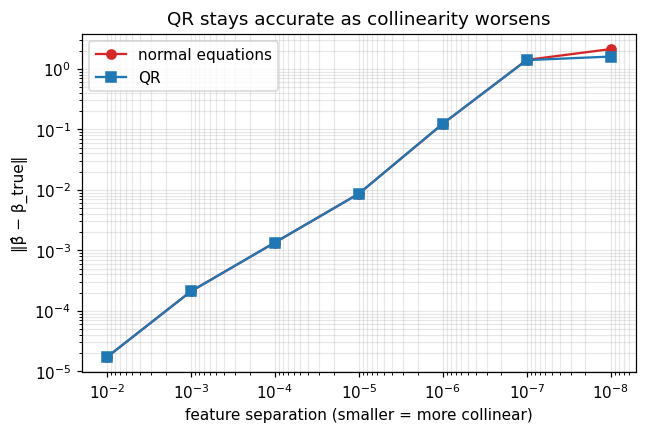

In [6]:
rng = np.random.default_rng(7)
n = 200
a = rng.normal(size=n)
beta_true = np.array([1.0, 2.0, -1.0])
gaps, err_normal, err_qr = [], [], []
for log_gap in range(2, 9):
    eps = 10.0 ** (-log_gap)
    X = np.column_stack([np.ones(n), a, a + eps * rng.normal(size=n)])
    y = X @ beta_true + rng.normal(scale=1e-6, size=n)
    gaps.append(eps)
    err_normal.append(np.linalg.norm(lstsq_normal(X, y) - beta_true))
    err_qr.append(np.linalg.norm(lstsq_qr(X, y) - beta_true))

plt.figure(figsize=(6.5, 4))
plt.loglog(gaps, err_normal, "o-", color="C3", label="normal denklemler")
plt.loglog(gaps, err_qr, "s-", color="C0", label="QR")
plt.gca().invert_xaxis()
plt.xlabel("öznitelik ayrımı (daha küçük = daha eşdoğrusal)")
plt.ylabel("‖β̂ − β_true‖")
plt.title("Eşdoğrusallık kötüleştikçe QR doğru kalır")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.show()

## Alıştırmalar

1. **İndirgenmiş ve tam QR.** Uzun bir $m\times n$ matris için, $Q$'muz $m\times n$'dir (indirgenmiş). Tam $m\times m$ $Q$'nun ne eklediğini ve onu ne zaman isteyeceğinizi açıklayın.
2. **QR ile determinant.** $Q$ ortogonal olduğundan ($|\det Q| = 1$), $|\det A| = \prod_i |R_{ii}|$. Bir kare matriste doğrulayın.
3. **Yeniden ortogonalleştir.** Kötü koşullanmış bir matrise Gram–Schmidt'i iki kez uygulayın ("Q'nun QR'si") ve ortogonalliğin ne kadar iyileştiğini ölçün.

In [7]:
# === Çözümler (önce kendiniz deneyin!) ===

# 2. R'nin köşegeninden determinant
M = np.random.default_rng(0).normal(size=(4, 4))
Q, R = qr_gram_schmidt(M)
check("|det M| == ∏|R_ii|", abs(np.prod(np.diag(R))), abs(np.linalg.det(M)), atol=1e-8)

# 3. yeniden ortogonalleştirme Q'yu keskinleştirir
rng = np.random.default_rng(1)
A_ill = np.column_stack([rng.normal(size=30)] * 3) + 1e-6 * rng.normal(size=(30, 3))
Q1, _ = qr_gram_schmidt(A_ill)
Q2, _ = qr_gram_schmidt(Q1)
print("1 geçişten sonra ‖QᵀQ−I‖ :", f"{np.max(np.abs(Q1.T@Q1 - np.eye(3))):.2e}")
print("2 geçişten sonra ‖QᵀQ−I‖:", f"{np.max(np.abs(Q2.T@Q2 - np.eye(3))):.2e}")

[PASS] |det M| == ∏|R_ii|               max|Δ| = 0.00e+00
‖QᵀQ−I‖ after 1 pass : 1.22e-04
‖QᵀQ−I‖ after 2 passes: 2.22e-16


## Özet ve sırada ne var

$A = QR$, ortonormalleştirmeyi yeniden kullanılabilir bir çarpanlamaya paketler; en küçük kareleri
çözmek tek bir üçgensel çözüme dönüşür ve koşul sayısının karesi hiç alınmaz. Householder yansımaları,
kararlı, üretim-kalitesinde yapıyı verir.

**Sırada — `09_ozdegerler_ozvektorler.ipynb`:** sistem çözmekten bir matrisin spektral yapısına
geçiyoruz — yalnızca gerdiği yönlere. Özdeğerler ve özvektörler PCA, PageRank ve SVD'ye kapı açar.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 4 · Ders 8*